Columns in dataset:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly']

Feature shape: (50000, 21)
Target shape : (50000, 1)
Iteration    0 | Loss: 27.5449
Iteration  100 | Loss: 3.6433
Iteration  200 | Loss: 0.5801
Iteration  300 | Loss: 0.1658
Iteration  400 | Loss: 0.1086
Iteration  500 | Loss: 0.1002
Iteration  600 | Loss: 0.0987
Iteration  700 | Loss: 0.0983
Iteration  800 | Loss: 0.0981
Iteration  900 | Loss: 0.0980

Gradient Descent Results

Final weights (theta):
[ 7.24382401  0.22693764  0.2125424   0.19921983  0.19250102  0.17573198
  0.16200885  0.16057318  0.14754696  0.043

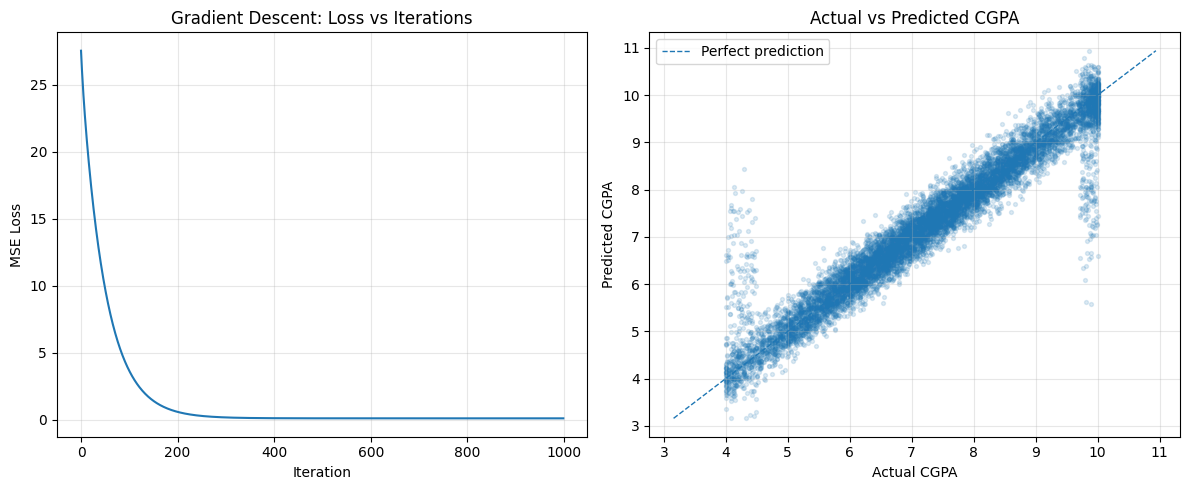

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression


# =========================================================
# 1. Load dataset
# =========================================================

df = pd.read_csv("/content/placement_predict_50k Dataset (1) (1).csv")

# Remove unwanted spaces from column names
df.columns = df.columns.str.strip()

print("Columns in dataset:")
print(df.columns.tolist())


# =========================================================
# 2. Set target column
# =========================================================

target_col = "CGPA"

# Check whether CGPA exists
if target_col not in df.columns:
    print("\nERROR: CGPA column was not found.")
    print("Available columns are:")
    print(df.columns.tolist())
    raise KeyError(
        "CGPA column not found. Check the column name printed above."
    )


# =========================================================
# 3. Separate features and target
# =========================================================

# Drop ID, target, and tier columns from features
drop_cols = [
    "StudentID",
    "CGPA",
    "CGPA_Tier"
]

feature_df = df.drop(
    columns=drop_cols,
    errors="ignore"
)


# =========================================================
# 4. Keep only numerical columns
# =========================================================

feature_df = feature_df.select_dtypes(
    include=[np.number]
)


# =========================================================
# 5. Handle missing values
# =========================================================

feature_df = feature_df.fillna(
    feature_df.median()
)


# =========================================================
# 6. Create X and y
# =========================================================

X = feature_df.values

y = df[target_col].values.reshape(-1, 1)


print("\nFeature shape:", X.shape)
print("Target shape :", y.shape)


# =========================================================
# 7. Train-test split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# =========================================================
# 8. Standardize features
# =========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =========================================================
# 9. Add bias/intercept column
# =========================================================

X_train_b = np.c_[
    np.ones((X_train.shape[0], 1)),
    X_train
]

X_test_b = np.c_[
    np.ones((X_test.shape[0], 1)),
    X_test
]


# =========================================================
# 10. Gradient Descent
# =========================================================

def gradient_descent(
    X,
    y,
    lr=0.01,
    n_iters=1000
):

    m, n = X.shape

    theta = np.zeros((n, 1))

    losses = []

    for i in range(n_iters):

        # Prediction
        y_pred = X @ theta

        # Error
        error = y_pred - y

        # Loss
        loss = (
            1 / (2 * m)
        ) * np.sum(error ** 2)

        losses.append(loss)

        # Gradient
        gradient = (
            1 / m
        ) * (X.T @ error)

        # Update weights
        theta = theta - lr * gradient

        if i % 100 == 0:
            print(
                f"Iteration {i:4d} | Loss: {loss:.4f}"
            )

    return theta, losses


# =========================================================
# 11. Train Gradient Descent model
# =========================================================

theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)


# =========================================================
# 12. Prediction
# =========================================================

y_pred = X_test_b @ theta


# =========================================================
# 13. Evaluate Gradient Descent model
# =========================================================

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)


print("\n===================================")
print("Gradient Descent Results")
print("===================================")

print("\nFinal weights (theta):")
print(theta.ravel())

print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")


# =========================================================
# 14. Scikit-learn Linear Regression
# =========================================================

sk_model = LinearRegression()

sk_model.fit(
    X_train,
    y_train.ravel()
)

sk_pred = sk_model.predict(
    X_test
)


# =========================================================
# 15. Evaluate Scikit-learn model
# =========================================================

sk_mse = mean_squared_error(
    y_test,
    sk_pred
)

sk_r2 = r2_score(
    y_test,
    sk_pred
)


print("\n===================================")
print("Sklearn Linear Regression Results")
print("===================================")

print(f"Sklearn MSE : {sk_mse:.4f}")
print(f"Sklearn R^2 : {sk_r2:.4f}")


# =========================================================
# 16. Plot results
# =========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# ---------------------------------------------------------
# Loss graph
# ---------------------------------------------------------

axes[0].plot(
    range(len(losses)),
    losses
)

axes[0].set_title(
    "Gradient Descent: Loss vs Iterations"
)

axes[0].set_xlabel(
    "Iteration"
)

axes[0].set_ylabel(
    "MSE Loss"
)

axes[0].grid(
    alpha=0.3
)


# ---------------------------------------------------------
# Actual vs predicted
# ---------------------------------------------------------

axes[1].scatter(
    y_test,
    y_pred,
    alpha=0.15,
    s=8
)

lims = [
    min(
        y_test.min(),
        y_pred.min()
    ),
    max(
        y_test.max(),
        y_pred.max()
    )
]

axes[1].plot(
    lims,
    lims,
    linestyle="--",
    linewidth=1,
    label="Perfect prediction"
)

axes[1].set_title(
    "Actual vs Predicted CGPA"
)

axes[1].set_xlabel(
    "Actual CGPA"
)

axes[1].set_ylabel(
    "Predicted CGPA"
)

axes[1].legend()

axes[1].grid(
    alpha=0.3
)


# =========================================================
# 17. Save and display plots
# =========================================================

plt.tight_layout()

plt.savefig(
    "gradient_descent_plots.png",
    dpi=150
)

print(
    "\nSaved plots to gradient_descent_plots.png"
)

plt.show()